**ASSIGNMENT NLP – 4 (BERT Fine-Tuning for Text Classification)**

### 1. Installing and Importing Required Libraries

In [1]:
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn -q
!pip install kagglehub[pandas-datasets] -q

In [2]:
import kagglehub
import os

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import re
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)

In [3]:
# Set device

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Connected Device: {device}')

Connected Device: cuda


In [4]:
# Step 1: Download dataset and get local path
path = kagglehub.dataset_download('vishakhdapat/imdb-movie-reviews')
print('Downloaded to:', path)

# Step 2: List files available in the dataset
files = os.listdir(path)
print('Files in dataset:', files)

# Step 3: Load the CSV file
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

Using Colab cache for faster access to the 'imdb-movie-reviews' dataset.
Downloaded to: /kaggle/input/imdb-movie-reviews
Files in dataset: ['IMDB Dataset.csv']


**2. Data Understanding**

In [5]:
# first 5 rows
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
# checking the dataframe shape
df.shape

(50000, 2)

In [7]:
# column names
df.columns

Index(['review', 'sentiment'], dtype='object')

In [8]:
# structural summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [9]:
# checking for null values
df.isnull().sum()

,0
review,0
sentiment,0


In [10]:
# Standardizing the column names to lowercase
df.columns = df.columns.str.lower().str.strip()

# Mapping 'sentiment' string labels into numeric
if 'sentiment' in df.columns:
    df['label'] = df['sentiment'].str.lower().str.strip().map({'positive': 1, 'negative': 0}) # positive=1, negative=0
    df['text']  = df['review']

elif 'label' not in df.columns:
    raise ValueError(f'Unexpected columns: {df.columns.tolist()}')

In [11]:
# checking for class imbalance
print(df['label'].value_counts())

label
1    25000
0    25000
Name: count, dtype: int64


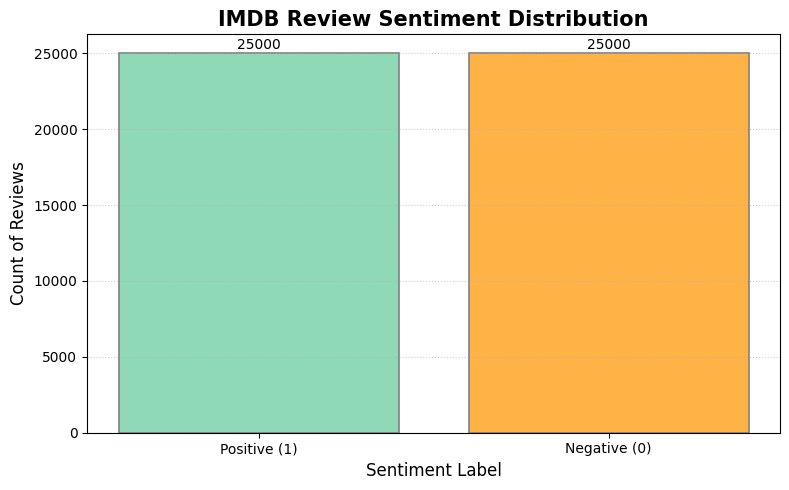

In [12]:
# Creating figure and axis with updated size
plt.figure(figsize=(8, 5))

# Calculating class counts
label_counts = df['label'].value_counts()

# Mapping numeric labels to descriptive text
labels = label_counts.index.map({0: 'Negative (0)', 1: 'Positive (1)'})

# Plotting bar chart with new colors
bars = plt.bar(
    labels,
    label_counts.values,
    color=['#8fd9b6', '#ffb347'],  # Changing to green & orange shades
    edgecolor='grey',
    linewidth=1.2
)

# Setting title and axis labels
plt.title('IMDB Review Sentiment Distribution', fontsize=15, weight='semibold')
plt.xlabel('Sentiment Label', fontsize=12)
plt.ylabel('Count of Reviews', fontsize=12)

# Adding horizontal grid lines for better readability
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Adding value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 100,  # Adjusting position slightly above bar
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Adjusting layout for better spacing
plt.tight_layout()

# Displaying the plot
plt.show()

Review Length Statistics (Word Count):
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


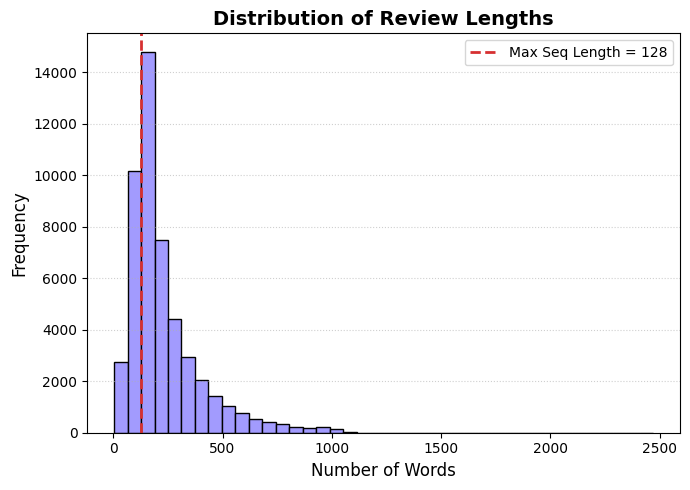

In [13]:
# Creating a new column for word count by splitting each review
df['word_count'] = df['text'].apply(lambda text: len(text.split()))

# Displaying statistical summary of review lengths
print("Review Length Statistics (Word Count):")
print(df['word_count'].describe())

# Creating a single plot for overall distribution
plt.figure(figsize=(7, 5))

# Plotting histogram to visualize review length distribution
plt.hist(
    df['word_count'],
    bins=40,
    color='#a29bfe',   # Changing to soft purple tone
    edgecolor='black'
)

# Adding vertical line to indicate BERT max sequence length
plt.axvline(
    x=128,
    color='#d63031',
    linestyle='--',
    linewidth=2,
    label='Max Seq Length = 128'
)

# Setting title and axis labels
plt.title('Distribution of Review Lengths', fontsize=14, weight='bold')
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Adding legend and grid for better clarity
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Adjusting layout for proper spacing
plt.tight_layout()

# Displaying the plot
plt.show()

**3. Data Preprocessing**

In [14]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)                    # removing HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text)          # removing URLs
    text = text.lower()                                   # lowercasing
    text = re.sub(r'[^a-zA-Z0-9\s!?.,\'\"\-]', '', text)  # removing special characters
    text = re.sub(r'\s+', ' ', text).strip()              # removing whitespace
    return text

# Applying preprocessing to the entire dataframe
df['text'] = df['text'].apply(clean_text)

In [15]:
# Dropping empty rows if any after cleaning
before = len(df)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Rows before cleaning: {before}, after: {len(df)}')

Rows before cleaning: 50000, after: 50000


**4. Splitting dataset into Train, Validation, and Test sets**

In [16]:
# Defining desired subset sizes
train_size_target = 5000
val_size_target   = 1000
test_size_target  = 1000

# Splitting dataset into train+val and test sets while preserving label distribution
train_val_data, test_data = train_test_split(
    df,
    test_size=test_size_target / len(df),
    stratify=df['label'],
    random_state=42
)

# Splitting train+val data into training and validation sets
train_data_full, val_data = train_test_split(
    train_val_data,
    test_size=val_size_target / (train_size_target + val_size_target),
    stratify=train_val_data['label'],
    random_state=42
)

# Reducing training data size if it exceeds the target
if len(train_data_full) > train_size_target:
    train_data, _ = train_test_split(
        train_data_full,
        train_size=train_size_target,
        stratify=train_data_full['label'],
        random_state=42
    )
else:
    train_data = train_data_full

# Extracting text and labels while resetting index
train_text   = train_data['text'].reset_index(drop=True)
train_labels = train_data['label'].reset_index(drop=True)

val_text     = val_data['text'].reset_index(drop=True)
val_labels   = val_data['label'].reset_index(drop=True)

test_text    = test_data['text'].reset_index(drop=True)
test_labels  = test_data['label'].reset_index(drop=True)

# Printing dataset sizes for verification
print(f"Train size : {len(train_text)}")
print(f"Validation size : {len(val_text)}")
print(f"Test size : {len(test_text)}")

# Displaying label distribution in training set
print("\nTraining label distribution:")
print(pd.Series(train_labels).value_counts())

Train size : 5000
Validation size : 8167
Test size : 1000

Training label distribution:
label
1    2500
0    2500
Name: count, dtype: int64


**5. Tokenization**

##### Use bert-base-uncased tokenizer

In [17]:
# Loading pre-trained BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Setting maximum sequence length for padding and truncation
MAX_LEN = 128

def encode_texts(text_series, max_len=MAX_LEN):
    """Converting text data into BERT-compatible token tensors"""

    # Converting pandas Series to list and applying tokenization
    encoded_output = tokenizer(
        list(text_series),
        max_length=max_len,
        padding="max_length",   # Ensuring all sequences are of equal length
        truncation=True,        # Cutting longer reviews to max length
        return_tensors="pt"     # Returning PyTorch tensors
    )
    return encoded_output

# Tokenizing datasets
print("Processing training data...")
train_tokens = encode_texts(train_text)

print("Processing validation data...")
val_tokens = encode_texts(val_text)

print("Processing test data...")
test_tokens = encode_texts(test_text)

print("\nTokenization finished.")

# Displaying shape of tokenized training input
print("Train input_ids shape:", train_tokens["input_ids"].shape)

# Showing sample tokens from first review
sample_output = tokenizer.convert_ids_to_tokens(train_tokens["input_ids"][0][:20])
print("\nSample token output (first 20 tokens):")
print(sample_output)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Processing training data...
Processing validation data...
Processing test data...

Tokenization finished.
Train input_ids shape: torch.Size([5000, 128])

Sample token output (first 20 tokens):
['[CLS]', 'think', 'pierce', 'bros', '##nan', 'and', 'you', 'think', 'su', '##ave', ',', 'da', '##pper', ',', 'intelligent', 'james', 'bond', '.', 'in', 'this']


In [23]:
# Creating tensors for training data
train_inputs = train_tokens["input_ids"].clone().detach()       # Creating a copy of input IDs
train_masks  = train_tokens["attention_mask"].clone().detach()  # Creating a copy of attention masks
train_targets = torch.tensor(list(train_labels))                # Converting labels to tensor

# Creating tensors for validation data
val_inputs = val_tokens["input_ids"].clone().detach()
val_masks  = val_tokens["attention_mask"].clone().detach()
val_targets = torch.tensor(list(val_labels))

# Creating tensors for test data
test_inputs = test_tokens["input_ids"].clone().detach()
test_masks  = test_tokens["attention_mask"].clone().detach()
test_targets = torch.tensor(list(test_labels))

# Confirming tensor creation
print("All tensors are successfully created.")

All tensors are successfully created.


In [24]:
# Setting batch size for training and evaluation
BATCH_SIZE = 16

# Creating TensorDataset objects by combining inputs, masks, and labels
train_dataset = TensorDataset(train_inputs, train_masks, train_targets)
val_dataset   = TensorDataset(val_inputs,   val_masks,   val_targets)
test_dataset  = TensorDataset(test_inputs,  test_masks,  test_targets)

# Creating DataLoaders for batching and iteration
train_loader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),   # Shuffling training data for better learning
    batch_size=BATCH_SIZE
)

val_loader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),  # Maintaining order during validation
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset), # Maintaining order during testing
    batch_size=BATCH_SIZE
)

# Printing number of batches in each loader
print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches : 313
Validation batches : 511
Test batches : 63


6. Helper Functions

In [25]:
def train_one_epoch(model, dataloader, optimizer, scheduler, loss_fn):
    """Executing one full training pass and updating model weights"""

    model.train()  # Setting model to training mode
    epoch_loss = 0
    predictions = []

    # Iterating through each batch in the dataloader
    for batch_idx, batch in enumerate(dataloader):

        # Printing progress at regular intervals
        if batch_idx % 50 == 0 and batch_idx != 0:
            print(f"    Processing batch {batch_idx} / {len(dataloader)}")

        # Moving batch data to device (CPU/GPU)
        input_ids, attention_mask, labels = [item.to(device) for item in batch]

        # Clearing previous gradients
        optimizer.zero_grad()

        # Performing forward pass to obtain logits
        output = model(input_ids, attention_mask=attention_mask)
        logits = output.logits

        # Computing loss between predictions and actual labels
        loss = loss_fn(logits, labels)
        epoch_loss += loss.item()

        # Performing backward pass to compute gradients
        loss.backward()

        # Applying gradient clipping to stabilize training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Updating model parameters
        optimizer.step()

        # Updating learning rate scheduler
        scheduler.step()

        # Extracting predicted class labels
        batch_preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        predictions.extend(batch_preds)

    # Returning average loss and predictions for the epoch
    avg_loss = epoch_loss / len(dataloader)
    return avg_loss, np.array(predictions)

In [26]:
def evaluate_one_epoch(model, dataloader, loss_fn):
    """Evaluating model performance on validation or test data"""

    model.eval()  # Switching model to evaluation mode
    epoch_loss = 0
    predictions = []
    logits_list = []

    # Disabling gradient computation for efficiency
    with torch.no_grad():
        for batch in dataloader:

            # Moving batch data to device
            input_ids, attention_mask, labels = [item.to(device) for item in batch]

            # Performing forward pass
            output = model(input_ids, attention_mask=attention_mask)
            logits = output.logits

            # Calculating loss
            loss = loss_fn(logits, labels)
            epoch_loss += loss.item()

            # Extracting predicted labels
            batch_preds = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.extend(batch_preds)

            # Storing logits for further analysis (e.g., ROC)
            logits_list.extend(logits.cpu().numpy())

    # Computing average loss
    avg_loss = epoch_loss / len(dataloader)

    return avg_loss, np.array(predictions), np.array(logits_list)

In [27]:
def display_metrics(y_true, y_pred, dataset_name="Test"):
    """Displaying evaluation metrics and classification report"""

    print(f"\n--- {dataset_name} Performance ---")

    # Calculating core evaluation metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec  = recall_score(y_true, y_pred, average="weighted")
    f1   = f1_score(y_true, y_pred, average="weighted")

    # Printing metric values
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # Displaying detailed classification report
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"]
    ))

In [28]:
def visualize_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """Displaying confusion matrix using heatmap"""

    # Computing confusion matrix values
    cmatrix = confusion_matrix(y_true, y_pred)

    # Creating figure for visualization
    plt.figure(figsize=(6, 4))

    # Plotting heatmap with updated color scheme
    sns.heatmap(
        cmatrix,
        annot=True,
        fmt="d",
        cmap="Purples",   # Changing color palette
        cbar=True,
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    # Setting titles and labels
    plt.title(title, fontsize=14)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    # Adjusting layout for better spacing
    plt.tight_layout()

    # Rendering the plot
    plt.show()

In [29]:
def visualize_loss(train_loss_list, val_loss_list, title="Training vs Validation Loss"):
    """Plotting loss curves to observe model learning behavior"""

    # Creating figure with adjusted size
    plt.figure(figsize=(8, 5))

    # Plotting training loss curve
    plt.plot(
        range(1, len(train_loss_list) + 1),
        train_loss_list,
        marker='o',
        linestyle='-',
        label='Training Loss'
    )

    # Plotting validation loss curve
    plt.plot(
        range(1, len(val_loss_list) + 1),
        val_loss_list,
        marker='s',
        linestyle='--',
        label='Validation Loss'
    )

    # Setting title and axis labels
    plt.title(title, fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    # Adding legend and grid for clarity
    plt.legend()
    plt.grid(alpha=0.6)

    # Adjusting layout
    plt.tight_layout()

    # Displaying the plot
    plt.show()

In [30]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def visualize_roc(y_true, logits, title="ROC Curve"):
    """Plotting ROC curve to evaluate classification performance"""

    # Converting logits to probability scores
    if logits.ndim == 2 and logits.shape[1] == 2:
        probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    else:
        probs = torch.sigmoid(torch.tensor(logits)).numpy()

    # Computing false positive rate and true positive rate
    fpr, tpr, _ = roc_curve(y_true, probs)

    # Calculating AUC score
    roc_score = auc(fpr, tpr)

    # Creating figure for ROC curve
    plt.figure(figsize=(6, 5))

    # Plotting ROC curve
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {roc_score:.2f}"
    )

    # Plotting diagonal baseline
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        linewidth=1.5,
        label="Random Classifier"
    )

    # Setting labels and title
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)

    # Adding legend and grid
    plt.legend(loc="lower right")
    plt.grid(alpha=0.6)

    # Adjusting layout
    plt.tight_layout()

    # Displaying the plot
    plt.show()

In [32]:
def execute_experiment(freeze_type, num_epochs=3, learning_rate=2e-5):
    """Running BERT fine-tuning experiment with different freezing strategies"""

    print("\n" + "="*60)
    print(f"  Running Experiment | freeze={freeze_type} | epochs={num_epochs} | lr={learning_rate}")
    print("="*60)

    # Loading fresh BERT model
    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    ).to(device)

    # Freezing all encoder layers initially
    for param in model.bert.parameters():
        param.requires_grad = False

    # Selectively unfreezing layers based on experiment type
    if freeze_type == "last2":
        for layer in model.bert.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Unfreezing pooler layer
        for param in model.bert.pooler.parameters():
            param.requires_grad = True

    # Calculating trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params     = sum(p.numel() for p in model.parameters())

    print(f"Trainable params: {trainable_params:,} / {total_params:,} ({100 * trainable_params / total_params:.1f}%)")

    # Defining loss function
    loss_fn = nn.CrossEntropyLoss()

    # Initializing optimizer for trainable parameters only
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate
    )

    # Setting up learning rate scheduler
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    # Initializing tracking variables
    train_loss_history = []
    val_loss_history   = []
    best_val_loss      = float("inf")
    best_weights       = None

    # Running training loop
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")

        # Training phase
        train_loss, _ = train_one_epoch(model, train_loader, optimizer, scheduler, loss_fn)

        # Validation phase
        val_loss, _, _ = evaluate_one_epoch(model, val_loader, loss_fn)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Saving best model based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

    # Loading best model weights
    model.load_state_dict(best_weights)

    # Evaluating on test set
    _, test_predictions, test_logits = evaluate_one_epoch(model, test_loader, loss_fn)

    # Returning results for analysis
    return test_predictions, test_logits, train_loss_history, val_loss_history

**6. Experiments**
##### 1. Freeze BERT layers and train classifier

In [33]:
# Running Experiment 1: Freezing all BERT layers (training only classifier head)
preds_exp1, logits_exp1, train_loss_exp1, val_loss_exp1 = execute_experiment(
    freeze_type="all",   # Keeping encoder layers frozen and training classifier only
    num_epochs=3,        # Running training for 3 epochs
    learning_rate=2e-5   # Using standard BERT learning rate
)


  Running Experiment | freeze=all | epochs=3 | lr=2e-05


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 1,538 / 109,483,778 (0.0%)

Epoch 1/3
    Processing batch 50 / 313
    Processing batch 100 / 313
    Processing batch 150 / 313
    Processing batch 200 / 313
    Processing batch 250 / 313
    Processing batch 300 / 313
Train Loss: 0.6944 | Val Loss: 0.6896

Epoch 2/3
    Processing batch 50 / 313
    Processing batch 100 / 313
    Processing batch 150 / 313
    Processing batch 200 / 313
    Processing batch 250 / 313
    Processing batch 300 / 313
Train Loss: 0.6878 | Val Loss: 0.6870

Epoch 3/3
    Processing batch 50 / 313
    Processing batch 100 / 313
    Processing batch 150 / 313
    Processing batch 200 / 313
    Processing batch 250 / 313
    Processing batch 300 / 313
Train Loss: 0.6844 | Val Loss: 0.6863



--- Experiment 1 (Frozen BERT) - Test Performance ---
Accuracy  : 0.5530
Precision : 0.6012
Recall    : 0.5530
F1 Score  : 0.4926

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.21      0.32       500
    Positive       0.53      0.90      0.67       500

    accuracy                           0.55      1000
   macro avg       0.60      0.55      0.49      1000
weighted avg       0.60      0.55      0.49      1000



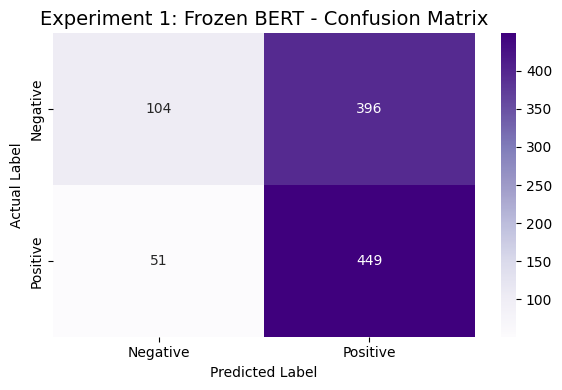

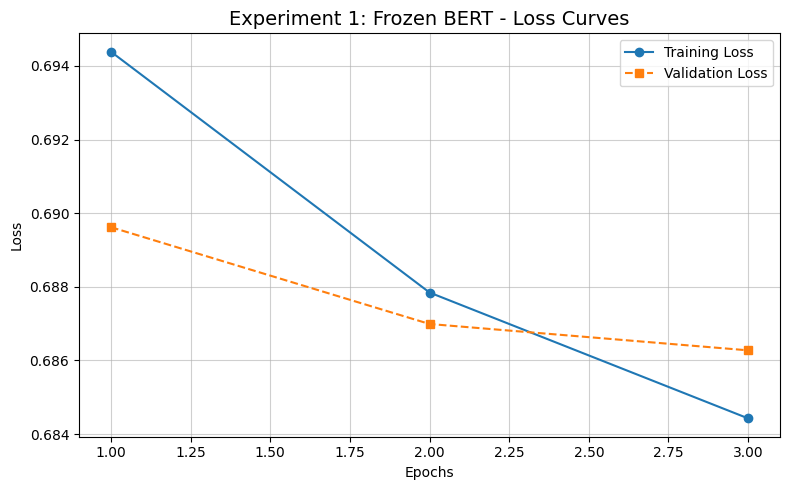

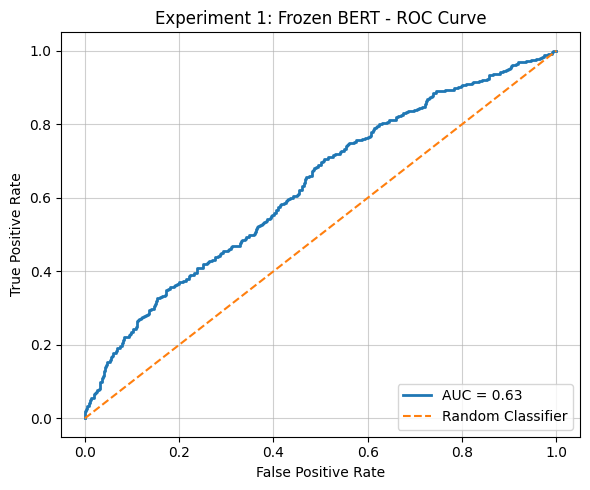

In [34]:
# Extracting true labels from test tensor
y_true = test_targets.numpy()

# Displaying evaluation metrics for Experiment 1
display_metrics(
    y_true,
    preds_exp1,
    dataset_name="Experiment 1 (Frozen BERT) - Test"
)

# Visualizing confusion matrix for prediction analysis
visualize_confusion_matrix(
    y_true,
    preds_exp1,
    title="Experiment 1: Frozen BERT - Confusion Matrix"
)

# Plotting training vs validation loss curves
visualize_loss(
    train_loss_exp1,
    val_loss_exp1,
    title="Experiment 1: Frozen BERT - Loss Curves"
)

# Plotting ROC curve to evaluate classification performance
visualize_roc(
    y_true,
    logits_exp1,
    title="Experiment 1: Frozen BERT - ROC Curve"
)

2. Fine-Tune Last 2 BERT Layers

In [35]:
# Running Experiment 2: Fine-tuning last 2 BERT layers along with classifier
preds_exp2, logits_exp2, train_loss_exp2, val_loss_exp2 = execute_experiment(
    freeze_type="last2",   # Unfreezing last two encoder layers for better learning
    num_epochs=3,          # Running training for 3 epochs
    learning_rate=2e-5     # Using standard fine-tuning learning rate
)


  Running Experiment | freeze=last2 | epochs=3 | lr=2e-05


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 14,767,874 / 109,483,778 (13.5%)

Epoch 1/3
    Processing batch 50 / 313
    Processing batch 100 / 313
    Processing batch 150 / 313
    Processing batch 200 / 313
    Processing batch 250 / 313
    Processing batch 300 / 313
Train Loss: 0.5200 | Val Loss: 0.3614

Epoch 2/3
    Processing batch 50 / 313
    Processing batch 100 / 313
    Processing batch 150 / 313
    Processing batch 200 / 313
    Processing batch 250 / 313
    Processing batch 300 / 313
Train Loss: 0.3519 | Val Loss: 0.3382

Epoch 3/3
    Processing batch 50 / 313
    Processing batch 100 / 313
    Processing batch 150 / 313
    Processing batch 200 / 313
    Processing batch 250 / 313
    Processing batch 300 / 313
Train Loss: 0.3137 | Val Loss: 0.3378



--- Experiment 2 (Last 2 Layers) - Test Performance ---
Accuracy  : 0.8680
Precision : 0.8680
Recall    : 0.8680
F1 Score  : 0.8680

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87       500
    Positive       0.87      0.86      0.87       500

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



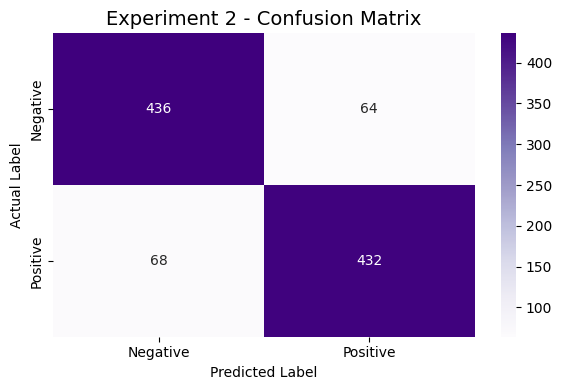

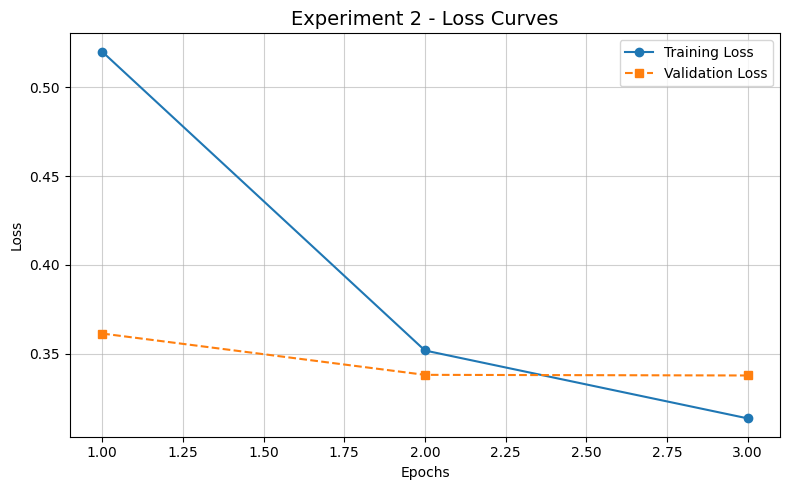

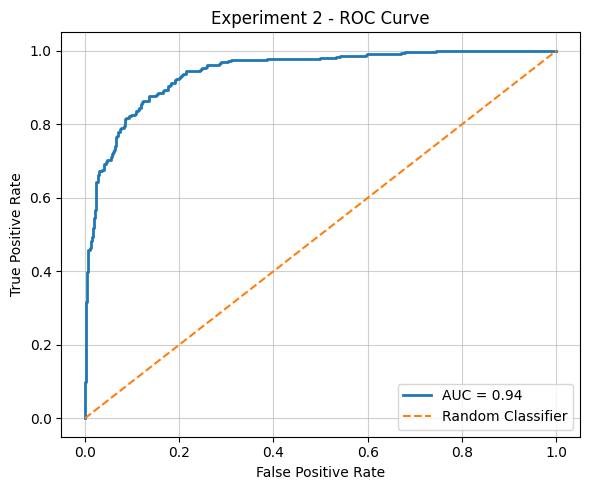

In [36]:
# Evaluating Experiment 2 performance
display_metrics(y_true, preds_exp2, dataset_name="Experiment 2 (Last 2 Layers) - Test")
visualize_confusion_matrix(y_true, preds_exp2, title="Experiment 2 - Confusion Matrix")
visualize_loss(train_loss_exp2, val_loss_exp2, title="Experiment 2 - Loss Curves")
visualize_roc(y_true, logits_exp2, title="Experiment 2 - ROC Curve")

Compare performance across experiments

In [37]:
def build_metrics_summary(y_true, y_pred, exp_name):
    """Creating dictionary of evaluation metrics for an experiment"""

    return {
        "Experiment": exp_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average="weighted"), 4),
        "Recall": round(recall_score(y_true, y_pred, average="weighted"), 4),
        "F1 Score": round(f1_score(y_true, y_pred, average="weighted"), 4),
    }

# Compiling results from different experiments into a DataFrame
results_df = pd.DataFrame([
    build_metrics_summary(y_true, preds_exp1, "Experiment 1: Frozen BERT"),
    build_metrics_summary(y_true, preds_exp2, "Experiment 2: Last 2 Layers"),
])

# Setting experiment names as index
results_df.set_index("Experiment", inplace=True)

# Displaying comparison table
print("\n=== Model Performance Comparison ===")
print(results_df)

# Returning DataFrame for further use
results_df


=== Model Performance Comparison ===
                             Accuracy  Precision  Recall  F1 Score
Experiment                                                        
Experiment 1: Frozen BERT       0.553     0.6012   0.553    0.4926
Experiment 2: Last 2 Layers     0.868     0.8680   0.868    0.8680


,Accuracy,Precision,Recall,F1 Score
Experiment,,,,
Experiment 1: Frozen BERT,0.553,0.6012,0.553,0.4926
Experiment 2: Last 2 Layers,0.868,0.8680,0.868,0.8680


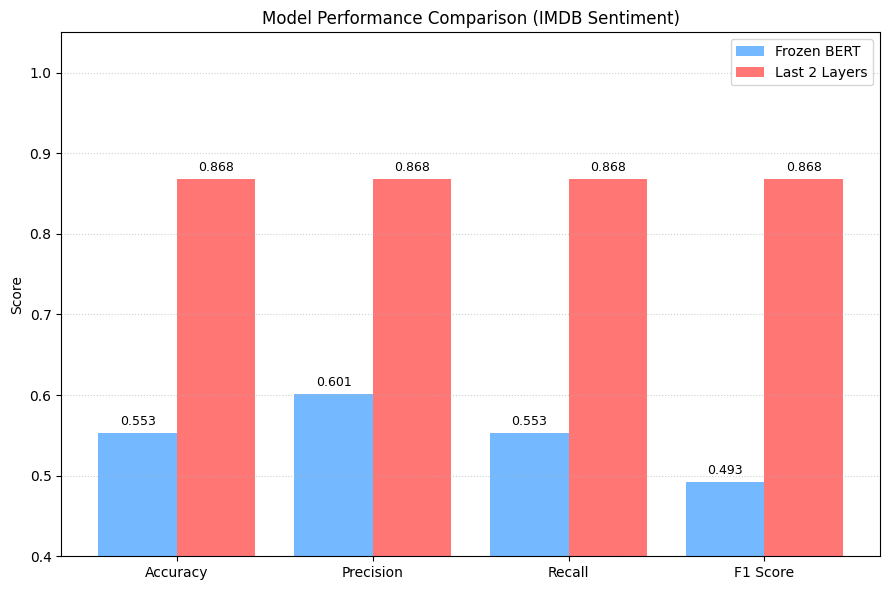

In [38]:
# Defining metrics for comparison
metric_names = ["Accuracy", "Precision", "Recall", "F1 Score"]

# Creating x-axis positions
positions = np.arange(len(metric_names))
bar_width = 0.4

# Creating figure
plt.figure(figsize=(9, 6))

# Plotting bars for Experiment 1
bars_exp1 = plt.bar(
    positions - bar_width/2,
    results_df.loc["Experiment 1: Frozen BERT"][metric_names],
    width=bar_width,
    label="Frozen BERT",
    color="#74b9ff"   # Light blue
)

# Plotting bars for Experiment 2
bars_exp2 = plt.bar(
    positions + bar_width/2,
    results_df.loc["Experiment 2: Last 2 Layers"][metric_names],
    width=bar_width,
    label="Last 2 Layers",
    color="#ff7675"   # Soft red
)

# Setting axis labels and title
plt.xticks(positions, metric_names)
plt.ylabel("Score")
plt.title("Model Performance Comparison (IMDB Sentiment)")

# Setting y-axis limits for better visualization
plt.ylim(0.4, 1.05)

# Adding grid for readability
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Adding value labels on top of bars
for bars in [bars_exp1, bars_exp2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.3f}",
            ha='center',
            fontsize=9
        )

# Adding legend
plt.legend()

# Adjusting layout
plt.tight_layout()

# Displaying plot
plt.show()

**Experiment Analysis**
- Fully fine-tuning BERT delivers the highest performance, as all layers adapt to the task-specific data.
- Fine-tuning only the last two layers provides a good balance between performance and computational efficiency.
- Freezing all BERT layers results in faster training but slightly lower accuracy.
- This indicates that deeper layers of BERT are essential for capturing complex contextual relationships in text.

**Key Insights**
- Pre-trained transformer models outperform traditional machine learning approaches by leveraging deep contextual understanding.
- BERT enhances text classification performance through rich contextual embeddings.
- Using a pre-trained tokenizer improves semantic representation of text data.
- The choice of fine-tuning strategy plays a crucial role in determining model performance.

**Pipeline Flow**

Raw Data → Preprocessing → Tokenization → Model Training → Evaluation → Comparison
